# 🔋 Exploration des données (EDA) - Prédiction du SoH

Ce notebook contient l'analyse exploratoire de notre jeu de données sur les batteries. L'objectif est de comprendre le comportement des différentes variables au fil des cycles de charge/décharge.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Configuration de l'affichage
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

# Chargement via notre module
sys.path.append(os.path.abspath('../src'))
from data_loader import load_data

df = load_data('../data/battery_dataset.csv')
display(df.head())

2026-03-14 13:28:32,590 - INFO - Chargement des données depuis : ../data/battery_dataset.csv
2026-03-14 13:28:32,669 - INFO - Données chargées : 29180 lignes, 7 colonnes.


,Voltage_measured,Current_measured,Temperature_measured,SoC,cycle_number,battery_id,SoH
0,3.964430,-0.912319,5.678270,97.699721,1,B0047,83.626322
1,3.843126,-0.995334,6.408629,92.510061,1,B0047,83.626322
2,3.796380,-0.995601,7.576325,87.422980,1,B0047,83.626322
3,3.749510,-0.995187,8.334522,82.444342,1,B0047,83.626322
4,3.699625,-0.995266,7.389032,77.465757,1,B0047,83.626322


## 1. Distribution des variables continues

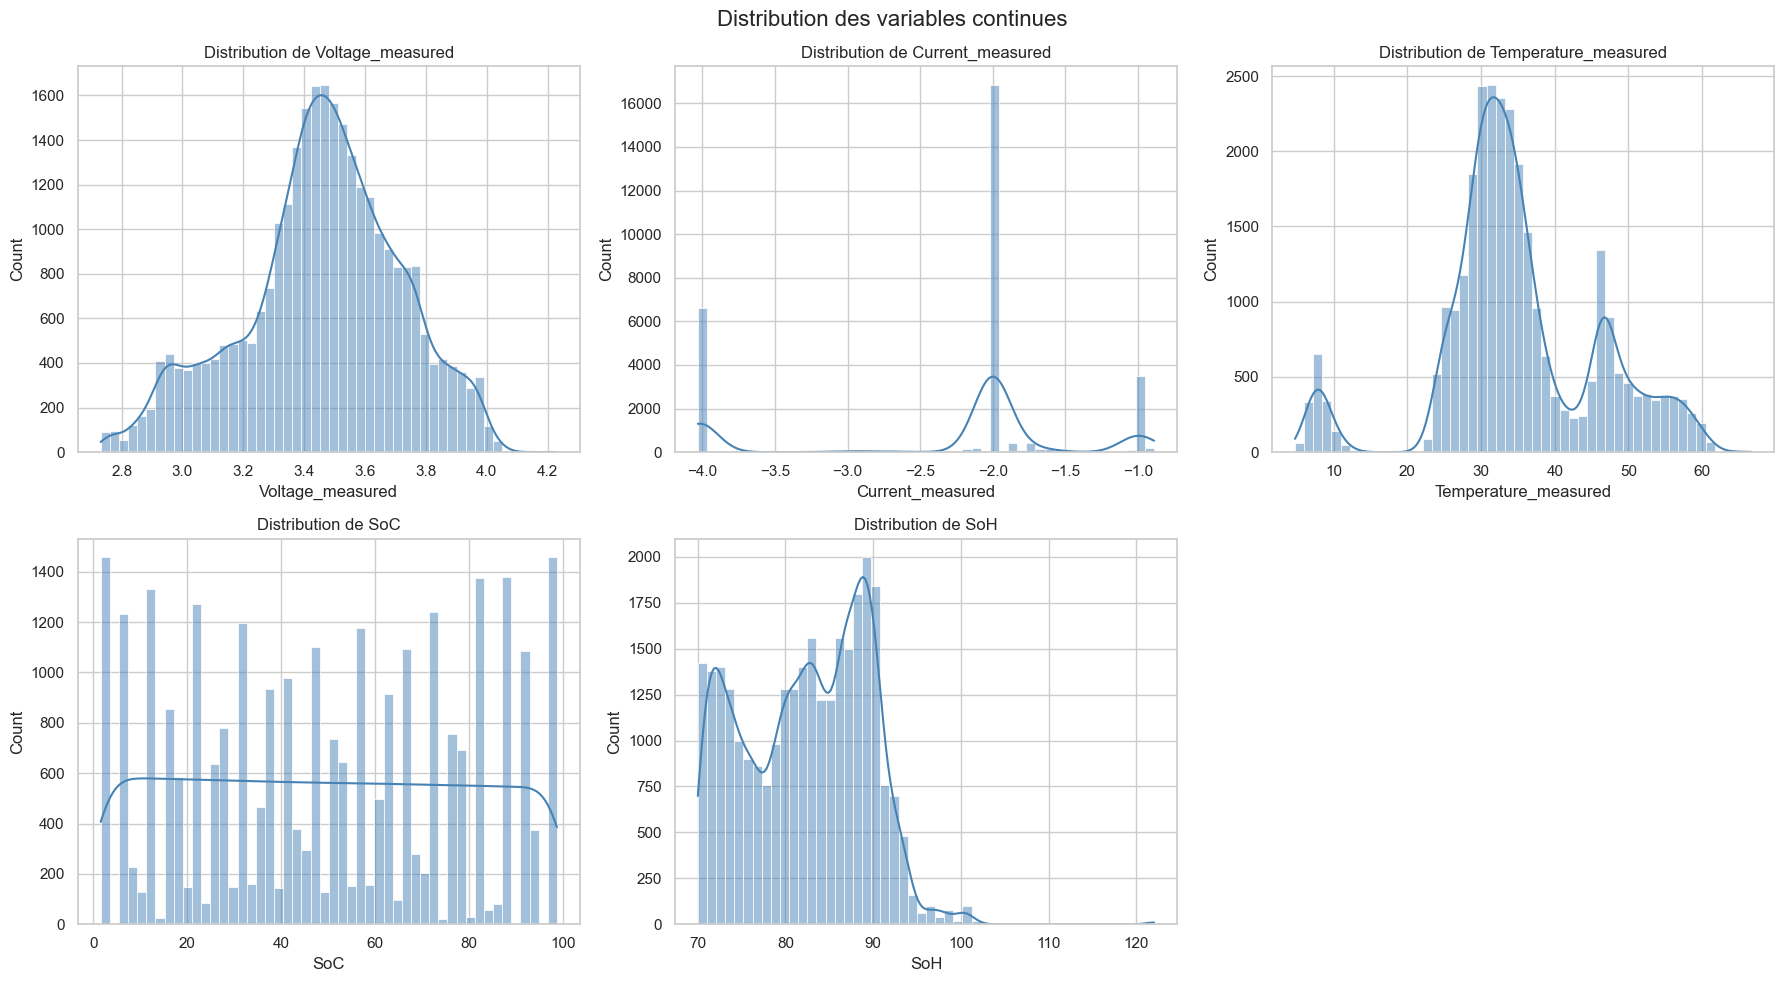

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution des variables continues', fontsize=16)

vars_to_plot = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'SoC', 'SoH']
for ax, var in zip(axes.flatten()[:5], vars_to_plot):
    sns.histplot(df[var], bins=50, kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution de {var}')

axes.flatten()[5].axis('off')
plt.tight_layout()
plt.show()

## 2. Évolution du SoH par cycle
Le SoH est notre variable cible. Voyons comment il se dégrade au fil des cycles pour chaque batterie.

In [3]:
fig = px.line(df, x='cycle_number', y='SoH', color='battery_id', 
              title='Évolution de l\'État de Santé (SoH) au fil des cycles',
              labels={'cycle_number': 'Nombre de cycles', 'SoH': 'State of Health (SoH)'})
fig.update_layout(hovermode='x unified')
fig.show()

## 3. Évolution des grandeurs physiques par cycle
Regardons comment évoluent la **Tension**, la **Température**, le **Courant** et le **SoC** sur la durée de vie de la batterie.

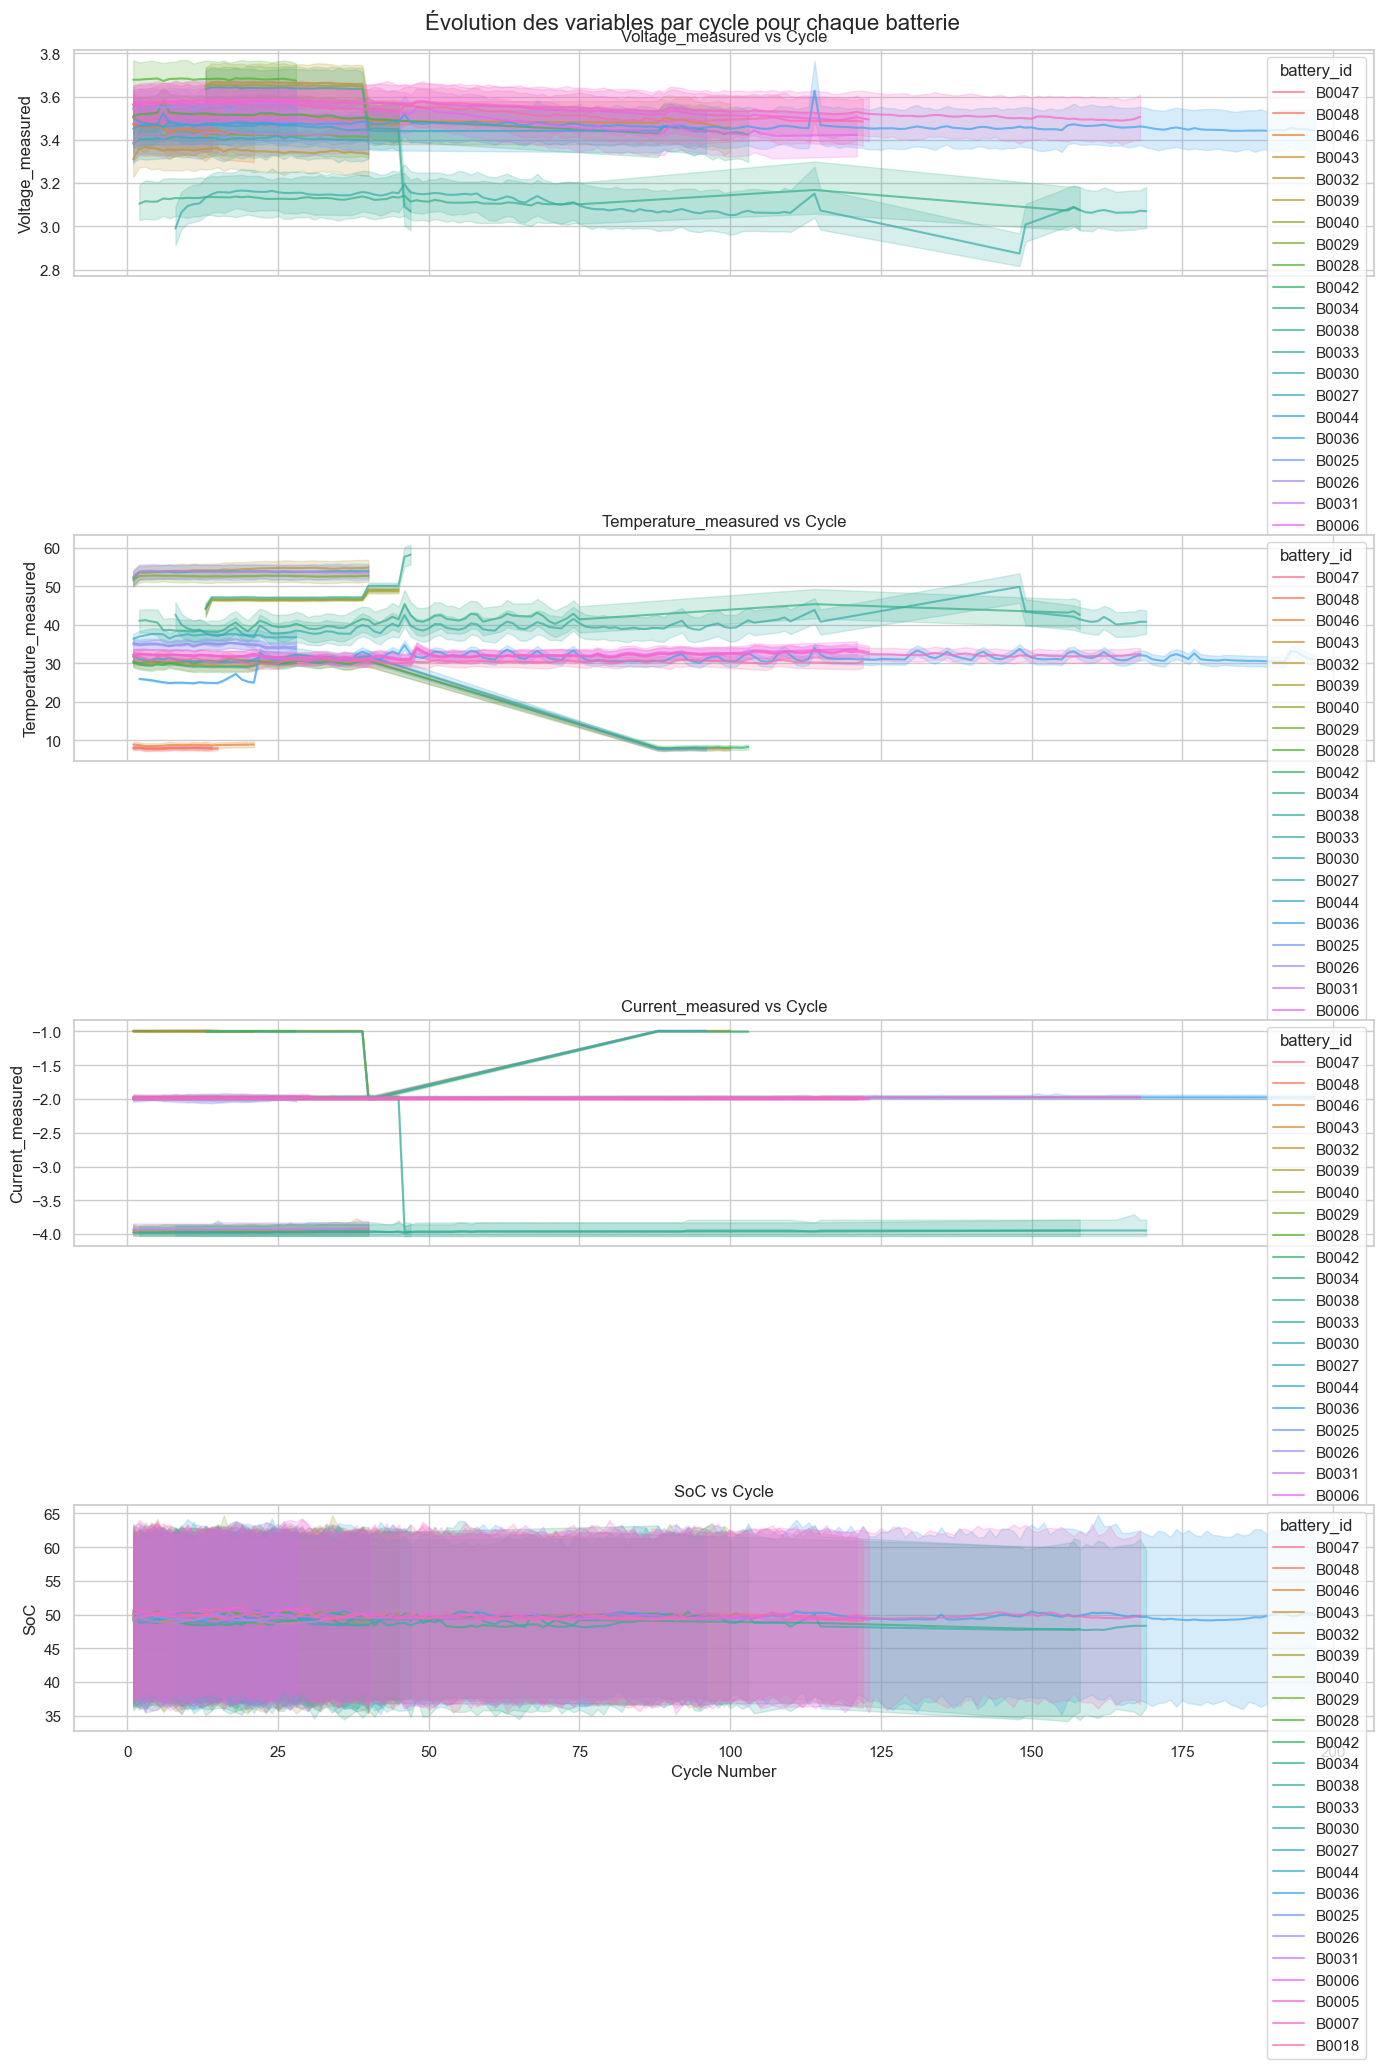

In [4]:
batteries = df['battery_id'].unique()

fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=True)
fig.suptitle('Évolution des variables par cycle pour chaque batterie', fontsize=16)

vars_to_plot = ['Voltage_measured', 'Temperature_measured', 'Current_measured', 'SoC']
colors = sns.color_palette('husl', len(batteries))

for ax, var in zip(axes, vars_to_plot):
    sns.lineplot(data=df, x='cycle_number', y=var, hue='battery_id', ax=ax, palette=colors, alpha=0.7)
    ax.set_title(f'{var} vs Cycle')
    ax.set_ylabel(var)

axes[-1].set_xlabel('Cycle Number')
plt.tight_layout()
plt.show()

## 4. Analyse des corrélations
Quelles sont les variables les plus corrélées à la dégradation du SoH ?

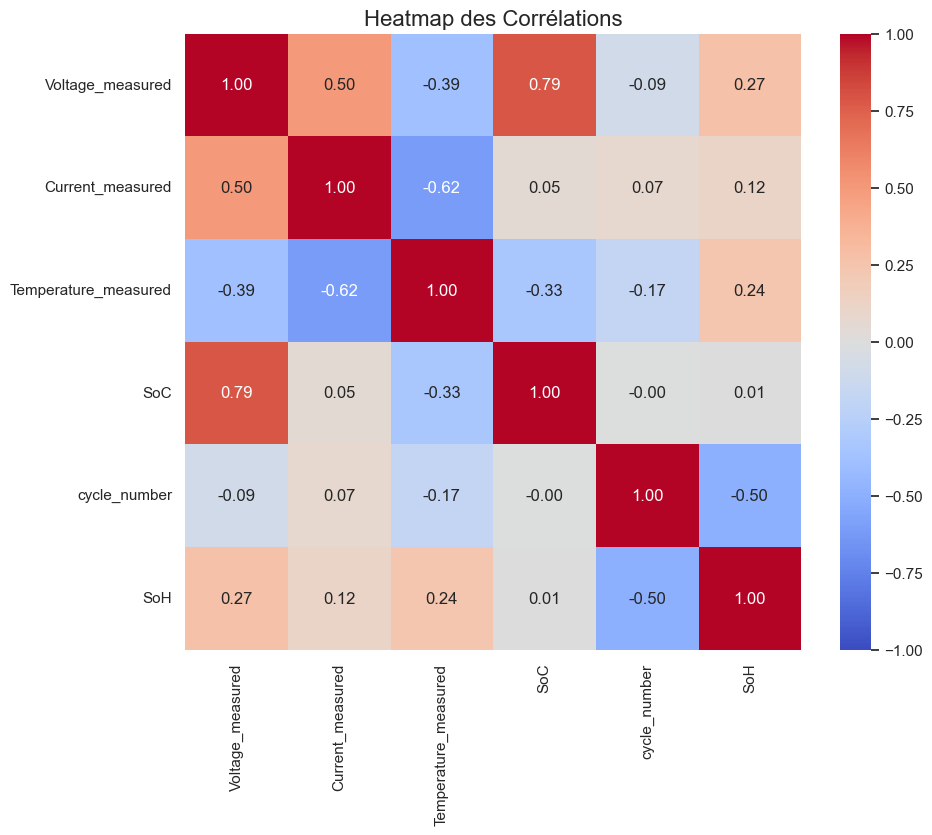

In [5]:
corr_matrix = df.drop(columns=['battery_id']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, square=True)
plt.title('Heatmap des Corrélations', fontsize=16)
plt.show()

### Zoom sur le SoH :
Isolons les variables qui impactent le plus notre cible.

C:\Users\Fureur\AppData\Local\Temp\ipykernel_26672\4091087122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=soh_corr['SoH'], y=soh_corr.index, palette='viridis')


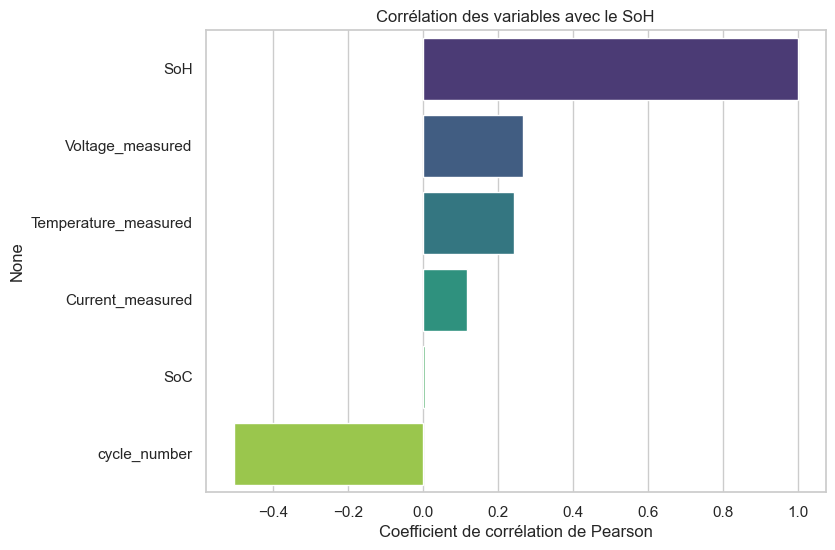

In [6]:
soh_corr = corr_matrix[['SoH']].sort_values(by='SoH', ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=soh_corr['SoH'], y=soh_corr.index, palette='viridis')
plt.title('Corrélation des variables avec le SoH')
plt.xlabel('Coefficient de corrélation de Pearson')
plt.show()

## Conclusion de l'EDA
- Le SoH diminue de manière continue, confirmant la dégradation.
- La Tension, Température et le Courant subissent des variations liées au vieillissement de la batterie.
- Le *cycle_number* est fortement corrélé négativement au SoH, ce qui est logique : plus on avance dans les cycles, plus la santé décline.

-> Prochaine étape : **Nettoyage et Création des Sliding Windows pour préparer les entrées temporelles du modèle LSTM.**